# Prefix trade-off

Sized for a half-width LaTeX figure. Numbers indicate prefix lengths; full steering, Prompt, and Unsteered are identified by the legend. PDF output is saved under `figs/`.

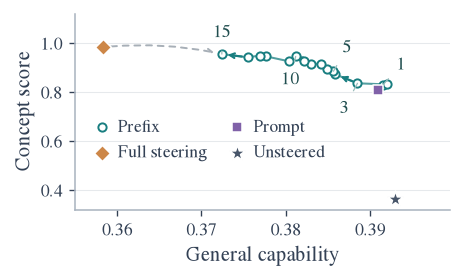

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from io import StringIO
from pathlib import Path

CSV_DATA = """series,prefix_len,general_capability,concept_score
Prefix,1,0.391573,0.8305
Prefix,2,0.391981,0.831017
Prefix,3,0.388518,0.835593
Prefix,4,0.385871,0.87229
Prefix,5,0.385667,0.884746
Prefix,6,0.384852,0.894407
Prefix,7,0.384241,0.915085
Prefix,8,0.383019,0.915085
Prefix,9,0.382205,0.928305
Prefix,10,0.381186,0.945085
Prefix,11,0.380372,0.925424
Prefix,12,0.377724,0.945085
Prefix,13,0.376909,0.948305
Prefix,14,0.375484,0.941864
Prefix,15,0.372429,0.954746
Full steering,,0.358376,0.98305
Unsteered,,0.392999,0.362712
Prompt,,0.390999,0.80732712
"""

df = pd.read_csv(StringIO(CSV_DATA))
early = df[df["series"] == "Prefix"].copy().sort_values("prefix_len")
all_pt = df[df["series"] == "Full steering"].iloc[0]
un_pt = df[df["series"] == "Unsteered"].iloc[0]
prompt_pt = df[df["series"] == "Prompt"].iloc[0]

# A single linear-axis view with distinct, muted method colors.
COLORS = {"early": "#197E80", "all": "#CD8748", "prompt": "#8061A8", "base": "#475569"}
# Match the paper typography and embed TrueType fonts in the PDF.
with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42}):
    fig, ax = plt.subplots(figsize=(3.35, 2.0), dpi=140)
    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.25, top=0.95)

    xy = early[["general_capability", "concept_score"]].to_numpy()
    ax.plot(xy[:, 0], xy[:, 1], color=COLORS["early"], lw=1.05, alpha=0.75, zorder=2)
    # Sparse arrows show increasing prefix length without crowding adjacent points.
    for start, end in [(2, 3), (4, 5), (8, 9), (13, 14)]:
        ax.annotate("", xy=xy[end], xytext=xy[start],
                    arrowprops=dict(arrowstyle="->", color=COLORS["early"],
                                    lw=1.1, shrinkA=3, shrinkB=3, mutation_scale=6), zorder=3)
    ax.scatter(xy[:, 0], xy[:, 1], s=18, facecolors="white",
               edgecolors=COLORS["early"], linewidths=1.0, label="Prefix", zorder=4)

    for point, marker, size, color, label in [
        (all_pt, "D", 34, COLORS["all"], "Full steering"),
        (prompt_pt, "s", 32, COLORS["prompt"], "Prompt"),
        (un_pt, "*", 75, COLORS["base"], "Unsteered"),
    ]:
        ax.scatter([point.general_capability], [point.concept_score],
                   marker=marker, s=size, facecolors=color, edgecolors="white",
                   linewidths=0.8, label=label, zorder=5)

    pt15 = early.loc[early.prefix_len.eq(15)].iloc[0]
    ax.add_patch(FancyArrowPatch(
        (all_pt.general_capability, all_pt.concept_score),
        (pt15.general_capability, pt15.concept_score),
        connectionstyle="arc3,rad=-0.08", arrowstyle="->", linestyle=(0, (3, 3)),
        color="#A7AFB7", lw=1.0, mutation_scale=6, shrinkA=4, shrinkB=4, zorder=1,
    ))

    # Offsets are in points; labels stay anchored when the data change.
    label_offsets = {1: (9, 10), 3: (-7, -13), 5: (7, 12), 10: (-3, -12), 15: (0, 11)}
    for length, offset in label_offsets.items():
        point = early.loc[early.prefix_len.eq(length)].iloc[0]
        ax.annotate(str(length), (point.general_capability, point.concept_score),
                    xytext=offset, textcoords="offset points", ha="center", va="center",
                    fontsize=9, color="#214F50",
                    arrowprops=dict(arrowstyle="-", color="#9BBEBD", lw=0.65,
                                    shrinkA=3, shrinkB=5), zorder=7)

    ax.set(xlim=(0.355, 0.3995), ylim=(0.32, 1.12),
           xticks=[0.36, 0.37, 0.38, 0.39], yticks=[0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel("General capability", fontsize=10.5, labelpad=3, color="#334155")
    ax.set_ylabel("Concept score", fontsize=10.5, labelpad=3, color="#334155")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#E6E9EC", linewidth=0.55)
    ax.tick_params(labelsize=9, colors="#334155", length=3, width=0.7)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#AAB4C0")
        ax.spines[side].set_linewidth(0.8)
    ax.legend(loc="lower left", bbox_to_anchor=(0.025, 0.20), frameon=False,
              fontsize=9, ncol=2, columnspacing=1.2, handletextpad=0.4,
              labelspacing=0.45, borderpad=0, handlelength=1.0, labelcolor="#334155")

    ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                if (path / "notebooks").is_dir() and (path / "figs").is_dir())
    output_path = ROOT / "figs" / "reproduced_prefix_tradeoff.pdf"
    fig.savefig(output_path, bbox_inches="tight", pad_inches=0.025)
    plt.show()
